# Bank Customer Churn Analysis
### CSIS3764 Semester Test 2 – Full Solution
---

## 2.1 Import Data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler

# Import data
dfcus = pd.read_csv("C:\\Users\\Julia\\Desktop\\CSIS3753\\Semester test 2\\Data Science Past Assessments\\Data Science Tests\\2023\\Test 2\\bank_customers.csv")

print("✅ Data loaded successfully!")
print(f"Shape: {dfcus.shape}")
print()
dfcus.head()

✅ Data loaded successfully!
Shape: (10127, 23)



,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_1,Naive_Bayes_Classifier_2
0,768805383,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 2.2 Inspect the Data

In [41]:
# Concise summary: index, dtype, columns, non-null values, memory usage
print("=" * 60)
print("DATAFRAME INFO (index, dtypes, non-null counts, memory)")
print("=" * 60)
dfcus.info(memory_usage='deep')

DATAFRAME INFO (index, dtypes, non-null counts, memory)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credi

In [42]:
# Number of unique values for each feature
print("=" * 60)
print("NUMBER OF UNIQUE VALUES PER FEATURE")
print("=" * 60)
print(dfcus.nunique().to_string())

NUMBER OF UNIQUE VALUES PER FEATURE
CLIENTNUM                   10127
Attrition_Flag                  2
Customer_Age                   45
Gender                          2
Dependent_count                 6
Education_Level                 7
Marital_Status                  4
Income_Category                 6
Card_Category                   4
Months_on_book                 44
Total_Relationship_Count        6
Months_Inactive_12_mon          7
Contacts_Count_12_mon           7
Credit_Limit                 6205
Total_Revolving_Bal          1974
Avg_Open_To_Buy              6813
Total_Amt_Chng_Q4_Q1         1158
Total_Trans_Amt              5033
Total_Trans_Ct                126
Total_Ct_Chng_Q4_Q1           830
Avg_Utilization_Ratio         964
Naive_Bayes_Classifier_1     1591
Naive_Bayes_Classifier_2      640


## 2.3 Discard First and Last 7 Columns

In [43]:
print("Columns BEFORE dropping:")
print(list(dfcus.columns))
print(f"Total columns: {len(dfcus.columns)}")
print()

# Drop first column (index 0) and last 7 columns without naming them
dfcus = dfcus.iloc[:, 1:-7]

print("Columns AFTER dropping first and last 7:")
print(list(dfcus.columns))
print(f"Total columns remaining: {len(dfcus.columns)}")
print()
dfcus.head()

Columns BEFORE dropping:
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_1', 'Naive_Bayes_Classifier_2']
Total columns: 23

Columns AFTER dropping first and last 7:
['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy']
Total columns remaining: 15



,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
0,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,5,1,3,12691.0,777,11914.0
1,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,6,1,2,8256.0,864,7392.0
2,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,4,1,0,3418.0,0,3418.0
3,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,3,4,1,3313.0,2517,796.0
4,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,5,1,0,4716.0,0,4716.0


## 2.4 Statistical Summary

In [44]:
# Statistical summary of ALL features (include='all' to cover object columns too)
print("=" * 60)
print("STATISTICAL SUMMARY – ALL FEATURES")
print("=" * 60)
dfcus.describe(include='all')

STATISTICAL SUMMARY – ALL FEATURES


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
count,10127,10127.000000,10127,10127.000000,10127,10127,10127,10127,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,2,NaN,2,NaN,7,4,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Existing Customer,NaN,F,NaN,Graduate,Married,Less than R40K,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,8500,NaN,5358,NaN,3128,4687,3561,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,46.325960,NaN,2.346203,NaN,NaN,NaN,NaN,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637
std,NaN,8.016814,NaN,1.298908,NaN,NaN,NaN,NaN,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324
min,NaN,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000
25%,NaN,41.000000,NaN,1.000000,NaN,NaN,NaN,NaN,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000
50%,NaN,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000
75%,NaN,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000


### 2.4.1 Deduction from Statistical Summary – Marital Status

In [45]:
print("""
DEDUCTION – MARITAL STATUS
============================================================
From the statistical summary the following can be deduced
about the customers' marital status:

1. COUNT  : There are 10 127 records in total, meaning that
            every customer has a marital status entry
            (no missing / NaN values in this column).

2. UNIQUE : There are 4 unique marital status categories:
            Married, Single, Unknown and Divorced.

3. TOP    : The most frequently occurring marital status is
            'Married', confirming it is the modal category.

4. FREQ   : Married customers appear 4 687 times, making them
            the largest group – roughly 46 % of all customers.
            Single customers (≈ 39 %) form the second-largest
            group, while Divorced and Unknown each represent
            only about 7 % of the dataset.

5. IMPLICATION: Because a notable portion of customers are
            labelled 'Unknown', any model trained on marital
            status should treat 'Unknown' as a distinct
            category rather than imputing a value, to avoid
            introducing bias.
============================================================
""")
print(dfcus['Marital_Status'].value_counts())


DEDUCTION – MARITAL STATUS
From the statistical summary the following can be deduced
about the customers' marital status:

1. COUNT  : There are 10 127 records in total, meaning that
            every customer has a marital status entry
            (no missing / NaN values in this column).

2. UNIQUE : There are 4 unique marital status categories:
            Married, Single, Unknown and Divorced.

3. TOP    : The most frequently occurring marital status is
            'Married', confirming it is the modal category.

4. FREQ   : Married customers appear 4 687 times, making them
            the largest group – roughly 46 % of all customers.
            Single customers (≈ 39 %) form the second-largest
            group, while Divorced and Unknown each represent
            only about 7 % of the dataset.

5. IMPLICATION: Because a notable portion of customers are
            labelled 'Unknown', any model trained on marital
            status should treat 'Unknown' as a distinct
        

## 2.5 Visualise the Data

<Figure size 640x480 with 0 Axes>

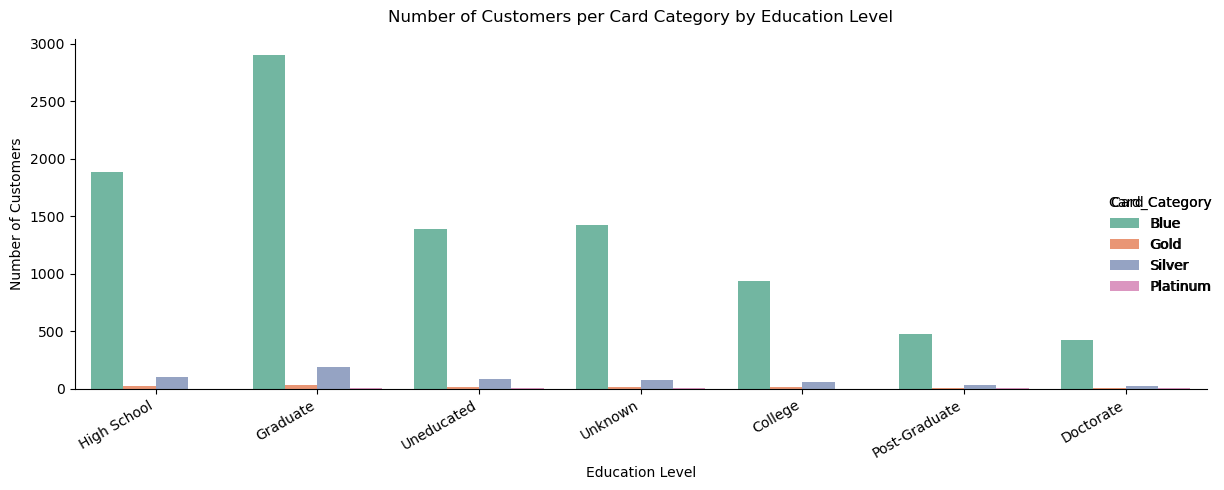

In [46]:
# ── Categorical plot: Card Category count per Education Level ──────────────
plt.figure()
g = sns.catplot(
    data=dfcus,
    x='Education_Level',
    hue='Card_Category',
    kind='count',
    height=5,
    aspect=2,
    palette='Set2'
)
g.set_xticklabels(rotation=30, ha='right')
g.set_axis_labels("Education Level", "Number of Customers")
g.add_legend(title="Card Category")
plt.title("Number of Customers per Card Category by Education Level", pad=12)
plt.tight_layout()
plt.show()
print()

In [47]:
print("""
DISCUSSION – Categorical Plot (Card Category vs Education Level)
================================================================
1. BLUE DOMINANCE: The Blue card category overwhelmingly
   dominates across every education level, indicating that
   it is the entry-level or default card assigned to most
   customers regardless of educational background.

2. GRADUATE & HIGH SCHOOL LEAD: Graduate and High School
   customers constitute the two largest groups in almost
   every card category, reflecting the overall distribution
   of education levels in the dataset.

3. PREMIUM CARDS ARE RARE: Gold, Silver, and especially
   Platinum cards appear in very small numbers across all
   education levels. This suggests that premium card
   ownership is not strongly tied to education level alone
   but may depend more on income or credit history.

4. UNKNOWN EDUCATION: A substantial 'Unknown' group exists
   across all card types – predominantly Blue – indicating
   that missing education data is a concern that could
   affect analyses that rely on this feature.

5. DOCTORATE & POST-GRADUATE: These highly educated groups
   are among the smallest in absolute count, yet they still
   mirror the Blue-dominated pattern seen elsewhere.
================================================================
""")


DISCUSSION – Categorical Plot (Card Category vs Education Level)
1. BLUE DOMINANCE: The Blue card category overwhelmingly
   dominates across every education level, indicating that
   it is the entry-level or default card assigned to most
   customers regardless of educational background.

2. GRADUATE & HIGH SCHOOL LEAD: Graduate and High School
   customers constitute the two largest groups in almost
   every card category, reflecting the overall distribution
   of education levels in the dataset.

3. PREMIUM CARDS ARE RARE: Gold, Silver, and especially
   Platinum cards appear in very small numbers across all
   education levels. This suggests that premium card
   ownership is not strongly tied to education level alone
   but may depend more on income or credit history.

4. UNKNOWN EDUCATION: A substantial 'Unknown' group exists
   across all card types – predominantly Blue – indicating
   that missing education data is a concern that could
   affect analyses that rely on this featu

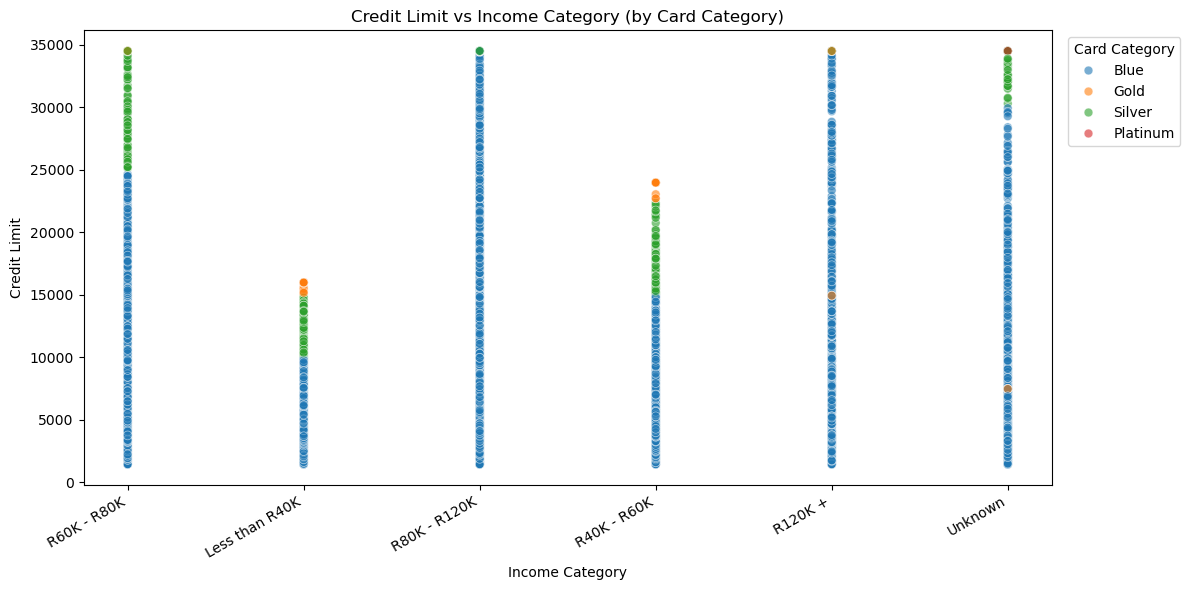

In [48]:
# ── Scatter plot: Income Category vs Credit Limit coloured by Card Category ──
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=dfcus,
    x='Income_Category',
    y='Credit_Limit',
    hue='Card_Category',
    palette='tab10',
    alpha=0.6,
    s=40
)
plt.xticks(rotation=30, ha='right')
plt.title("Credit Limit vs Income Category (by Card Category)")
plt.xlabel("Income Category")
plt.ylabel("Credit Limit")
plt.legend(title="Card Category", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()
print()

In [49]:
print("""
DISCUSSION – Scatter Plot (Income Category vs Credit Limit by Card Category)
=============================================================================
1. CREDIT LIMIT INCREASES WITH INCOME: There is a clear
   positive trend – customers in the higher income brackets
   (R80K–R120K and R120K+) tend to have higher credit limits,
   while the 'Less than R40K' group is concentrated at the
   lower end of the credit-limit axis.

2. BLUE CARD SPANS ALL INCOME LEVELS: Blue card holders
   appear across every income category and across the full
   range of credit limits, reinforcing its role as the
   universal default card.

3. GOLD & SILVER SKEW HIGHER: Gold and Silver card holders
   are more frequently found in the upper income brackets and
   corresponding higher credit limits, suggesting that these
   cards are issued to financially stronger customers.

4. PLATINUM IS RARE BUT HIGH-LIMIT: Platinum card holders
   are very few in number but tend to appear near the top of
   the credit-limit range, consistent with an exclusive,
   high-value card tier.

5. WIDE SPREAD WITHIN INCOME BANDS: Even within a single
   income bracket, credit limits vary considerably. This
   implies that income alone does not fully determine credit
   limit; other factors (card category, tenure, behaviour)
   also play a role.
=============================================================================
""")


DISCUSSION – Scatter Plot (Income Category vs Credit Limit by Card Category)
1. CREDIT LIMIT INCREASES WITH INCOME: There is a clear
   positive trend – customers in the higher income brackets
   (R80K–R120K and R120K+) tend to have higher credit limits,
   while the 'Less than R40K' group is concentrated at the
   lower end of the credit-limit axis.

2. BLUE CARD SPANS ALL INCOME LEVELS: Blue card holders
   appear across every income category and across the full
   range of credit limits, reinforcing its role as the
   universal default card.

3. GOLD & SILVER SKEW HIGHER: Gold and Silver card holders
   are more frequently found in the upper income brackets and
   corresponding higher credit limits, suggesting that these
   cards are issued to financially stronger customers.

4. PLATINUM IS RARE BUT HIGH-LIMIT: Platinum card holders
   are very few in number but tend to appear near the top of
   the credit-limit range, consistent with an exclusive,
   high-value card tier.

5. WIDE

## 2.6 Check Class Balance

Customer group counts:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64



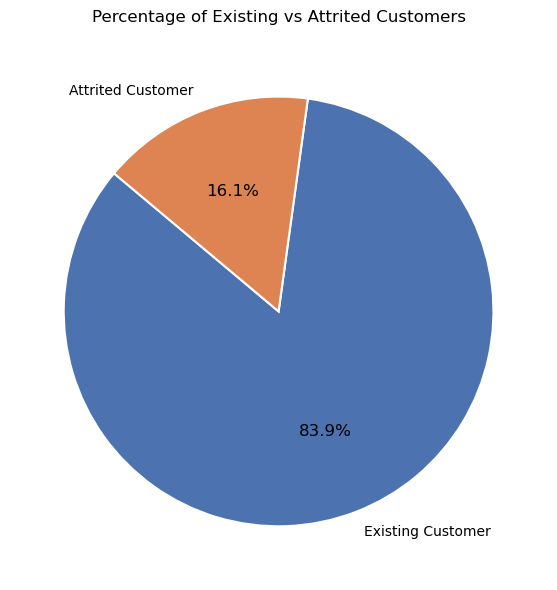

Existing Customer : 83.9%
Attrited Customer : 16.1%

⚠️  The data is IMBALANCED – Existing Customers make up ~84% of records.


In [50]:
# Count per class
class_counts = dfcus['Attrition_Flag'].value_counts()
print("Customer group counts:")
print(class_counts)
print()

# Pie chart
labels = class_counts.index.tolist()
sizes  = class_counts.values.tolist()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%',
    startangle=140,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(12)
ax.set_title("Percentage of Existing vs Attrited Customers", pad=15)
plt.tight_layout()
plt.show()

pct_existing = 100 * class_counts['Existing Customer'] / class_counts.sum()
pct_attrited = 100 * class_counts['Attrited Customer'] / class_counts.sum()
print(f"Existing Customer : {pct_existing:.1f}%")
print(f"Attrited Customer : {pct_attrited:.1f}%")
print()
print("⚠️  The data is IMBALANCED – Existing Customers make up ~84% of records.")

## 2.7 Balance the Data via Undersampling

In [51]:
print("Shape BEFORE resampling:", dfcus.shape)
print(dfcus['Attrition_Flag'].value_counts())
print()

# Separate X and y temporarily for resampling
X_temp = dfcus.drop(columns=['Attrition_Flag'])
y_temp = dfcus['Attrition_Flag']

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_temp, y_temp)

# Reassemble into dfcus_resampled
dfcus_resampled = X_res.copy()
dfcus_resampled.insert(0, 'Attrition_Flag', y_res.values)

print("Shape AFTER resampling:", dfcus_resampled.shape)
print(dfcus_resampled['Attrition_Flag'].value_counts())
print()
dfcus_resampled.head()

Shape BEFORE resampling: (10127, 15)
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Shape AFTER resampling: (3254, 15)
Attrition_Flag
Attrited Customer    1627
Existing Customer    1627
Name: count, dtype: int64



,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
21,Attrited Customer,62,F,0,Graduate,Married,Less than R40K,Blue,49,2,3,3,1438.3,0,1438.3
39,Attrited Customer,66,F,0,Doctorate,Married,Unknown,Blue,56,5,4,3,7882.0,605,7277.0
51,Attrited Customer,54,F,1,Graduate,Married,Less than R40K,Blue,40,2,3,1,1438.3,808,630.3
54,Attrited Customer,56,M,2,Graduate,Married,R120K +,Blue,36,1,3,3,15769.0,0,15769.0
61,Attrited Customer,48,M,2,Graduate,Married,R60K - R80K,Silver,35,2,4,4,34516.0,0,34516.0


In [52]:
print(dfcus_resampled['Attrition_Flag'].nunique())
print(dfcus_resampled['Gender'].nunique())
print(dfcus_resampled['Dependent_count'].nunique())
print(dfcus_resampled['Education_Level'].nunique())
print(dfcus_resampled['Marital_Status'].nunique())
print(dfcus_resampled['Income_Category'].nunique())
print(dfcus_resampled['Card_Category'].nunique())
print(dfcus_resampled['Total_Relationship_Count'].nunique())

2
2
6
7
4
6
4
6


## 2.8 Convert Text Values to Numeric

In [53]:
from sklearn.preprocessing import MinMaxScaler
le = LabelEncoder()
dfcus_resampled['Attrition_Flag'] = le.fit_transform(dfcus_resampled['Attrition_Flag'])
dfcus_resampled['Gender'] = le.fit_transform(dfcus_resampled['Gender'])

In [54]:
# Dependent count
Dep_dummies = pd.get_dummies(dfcus_resampled['Dependent_count'], prefix='Dependent_count', drop_first=False).astype(int)
dfcus_resampled = pd.concat([dfcus_resampled.drop(columns=['Dependent_count']), edu_dummies], axis=1)

# Education_Level
edu_dummies = pd.get_dummies(dfcus_resampled['Education_Level'], prefix='Education_Level', drop_first=False).astype(int)
dfcus_resampled = pd.concat([dfcus_resampled.drop(columns=['Education_Level']), edu_dummies], axis=1)

# Marital_Status
mar_dummies = pd.get_dummies(dfcus_resampled['Marital_Status'], prefix='Marital_Status', drop_first=False).astype(int)
dfcus_resampled = pd.concat([dfcus_resampled.drop(columns=['Marital_Status']), mar_dummies], axis=1)

# Income_Category
inc_dummies = pd.get_dummies(dfcus_resampled['Income_Category'], prefix='Income_Category', drop_first=False).astype(int)
dfcus_resampled = pd.concat([dfcus_resampled.drop(columns=['Income_Category']), inc_dummies], axis=1)

# Card_Category
card_dummies = pd.get_dummies(dfcus_resampled['Card_Category'], prefix='Card_Category', drop_first=False).astype(int)
dfcus_resampled = pd.concat([dfcus_resampled.drop(columns=['Card_Category']), card_dummies], axis=1)

scaler = MinMaxScaler()

# Reshape the data for the scaler (it expects a 2D array) and transform
# We apply it directly back to the column
dfcus_resampled['Months_on_book'] = scaler.fit_transform(dfcus_resampled[['Months_on_book']])
dfcus_resampled['Credit_Limit'] = scaler.fit_transform(dfcus_resampled[['Credit_Limit']])
dfcus_resampled['Total_Revolving_Bal'] = scaler.fit_transform(dfcus_resampled[['Total_Revolving_Bal']])
dfcus_resampled['Avg_Open_To_Buy'] = scaler.fit_transform(dfcus_resampled[['Avg_Open_To_Buy']])
dfcus_resampled.head()

,Attrition_Flag,Customer_Age,Gender,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,...,Income_Category_Less than R40K,Income_Category_R120K +,Income_Category_R40K - R60K,Income_Category_R60K - R80K,Income_Category_R80K - R120K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
21,0,62,0,0.837209,2,3,3,0.000000,0.000000,0.041587,...,1,0,0,0,0,0,1,0,0,0
39,0,66,0,1.000000,5,4,3,0.194805,0.240366,0.210761,...,0,0,0,0,0,1,1,0,0,0
51,0,54,0,0.627907,2,3,1,0.000000,0.321017,0.018176,...,1,0,0,0,0,0,1,0,0,0
54,0,56,1,0.534884,1,3,3,0.433244,0.000000,0.456813,...,0,1,0,0,0,0,1,0,0,0
61,0,48,1,0.511628,2,4,4,1.000000,0.000000,1.000000,...,0,0,0,1,0,0,0,0,0,1


## 2.9 Define X and y – Train / Test Split (80/20)

In [55]:
# X = all features; y = target
X = dfcus_resampled.drop(columns=['Attrition_Flag'])
y = dfcus_resampled['Attrition_Flag']

print("X shape:", X.shape)
print("y shape:", y.shape)
print()

# Verify all columns are numeric (pre-processing check)
non_numeric = X.select_dtypes(include='object').columns.tolist()
print("Non-numeric columns remaining:", non_numeric if non_numeric else "None ✅")
print()

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train dimensions:", X_train.shape)
print("X_test  dimensions:", X_test.shape)
print()
print("y_train class distribution:")
print(y_train.value_counts())
print()
print("y_test  class distribution:")
print(y_test.value_counts())

X shape: (3254, 37)
y shape: (3254,)

Non-numeric columns remaining: None ✅

X_train dimensions: (2603, 37)
X_test  dimensions: (651, 37)

y_train class distribution:
Attrition_Flag
1    1302
0    1301
Name: count, dtype: int64

y_test  class distribution:
Attrition_Flag
0    326
1    325
Name: count, dtype: int64


## 2.10 Train Classifiers – k-Fold Cross-Validation (k = 5)

In [56]:
# ── Instantiate classifiers ─────────────────────────────────────────────────
nb_clf  = GaussianNB()
svm_clf = SVC(gamma='auto', random_state=42)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Naive Bayes cross-validation ─────────────────────────────────────────────
nb_acc_scores = cross_val_score(nb_clf, X_train, y_train, cv=kfold, scoring='accuracy')
nb_f1_scores  = cross_val_score(nb_clf, X_train, y_train, cv=kfold, scoring='f1')

print("=" * 55)
print("NAIVE BAYES – 5-Fold Cross-Validation")
print("=" * 55)
print(f"  Accuracy  per fold : {np.round(nb_acc_scores, 4)}")
print(f"  Mean Accuracy      : {nb_acc_scores.mean():.4f}  (±{nb_acc_scores.std():.4f})")
print(f"  F1        per fold : {np.round(nb_f1_scores, 4)}")
print(f"  Mean F1 Score      : {nb_f1_scores.mean():.4f}  (±{nb_f1_scores.std():.4f})")
print()

# ── SVM cross-validation ─────────────────────────────────────────────────────
svm_acc_scores = cross_val_score(svm_clf, X_train, y_train, cv=kfold, scoring='accuracy')
svm_f1_scores  = cross_val_score(svm_clf, X_train, y_train, cv=kfold, scoring='f1')

print("=" * 55)
print("SUPPORT VECTOR MACHINE – 5-Fold Cross-Validation")
print("=" * 55)
print(f"  Accuracy  per fold : {np.round(svm_acc_scores, 4)}")
print(f"  Mean Accuracy      : {svm_acc_scores.mean():.4f}  (±{svm_acc_scores.std():.4f})")
print(f"  F1        per fold : {np.round(svm_f1_scores, 4)}")
print(f"  Mean F1 Score      : {svm_f1_scores.mean():.4f}  (±{svm_f1_scores.std():.4f})")
print()

# ── Summary table ────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Classifier': ['Naive Bayes', 'SVM (gamma=auto)'],
    'CV Accuracy': [nb_acc_scores.mean(), svm_acc_scores.mean()],
    'CV F1 Score': [nb_f1_scores.mean(), svm_f1_scores.mean()]
})
print("=" * 55)
print("SUMMARY TABLE")
print("=" * 55)
print(results_df.to_string(index=False))

NAIVE BAYES – 5-Fold Cross-Validation
  Accuracy  per fold : [0.6411 0.6699 0.6238 0.6192 0.6788]
  Mean Accuracy      : 0.6466  (±0.0240)
  F1        per fold : [0.6939 0.6993 0.6849 0.6413 0.7136]
  Mean F1 Score      : 0.6866  (±0.0245)

SUPPORT VECTOR MACHINE – 5-Fold Cross-Validation
  Accuracy  per fold : [0.7025 0.7083 0.6737 0.7173 0.7038]
  Mean Accuracy      : 0.7011  (±0.0147)
  F1        per fold : [0.699  0.7077 0.6852 0.7168 0.7027]
  Mean F1 Score      : 0.7023  (±0.0104)

SUMMARY TABLE
      Classifier  CV Accuracy  CV F1 Score
     Naive Bayes     0.646564     0.686597
SVM (gamma=auto)     0.701121     0.702274


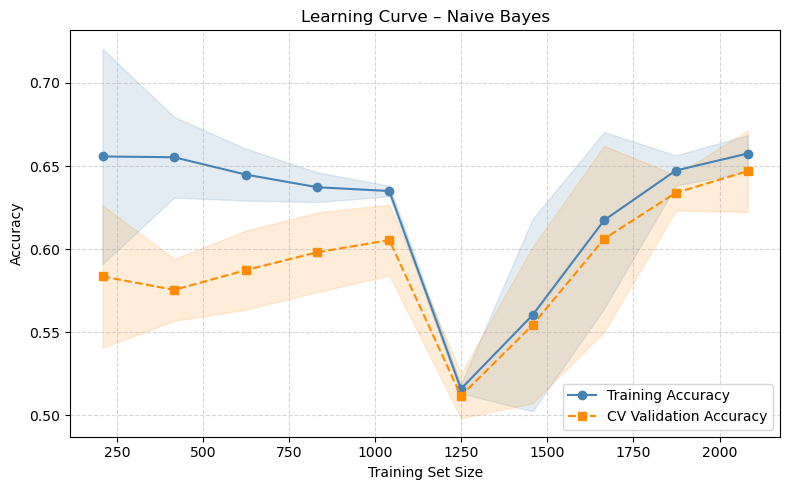

In [57]:
# ── Learning Curve – Naive Bayes ─────────────────────────────────────────────
train_sizes_nb, train_scores_nb, val_scores_nb = learning_curve(
    GaussianNB(), X_train, y_train,
    cv=kfold, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean_nb = train_scores_nb.mean(axis=1)
train_std_nb  = train_scores_nb.std(axis=1)
val_mean_nb   = val_scores_nb.mean(axis=1)
val_std_nb    = val_scores_nb.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_nb, train_mean_nb, 'o-', color='steelblue', label='Training Accuracy')
plt.fill_between(train_sizes_nb, train_mean_nb - train_std_nb, train_mean_nb + train_std_nb, alpha=0.15, color='steelblue')
plt.plot(train_sizes_nb, val_mean_nb, 's--', color='darkorange', label='CV Validation Accuracy')
plt.fill_between(train_sizes_nb, val_mean_nb - val_std_nb, val_mean_nb + val_std_nb, alpha=0.15, color='darkorange')
plt.title("Learning Curve – Naive Bayes")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print()

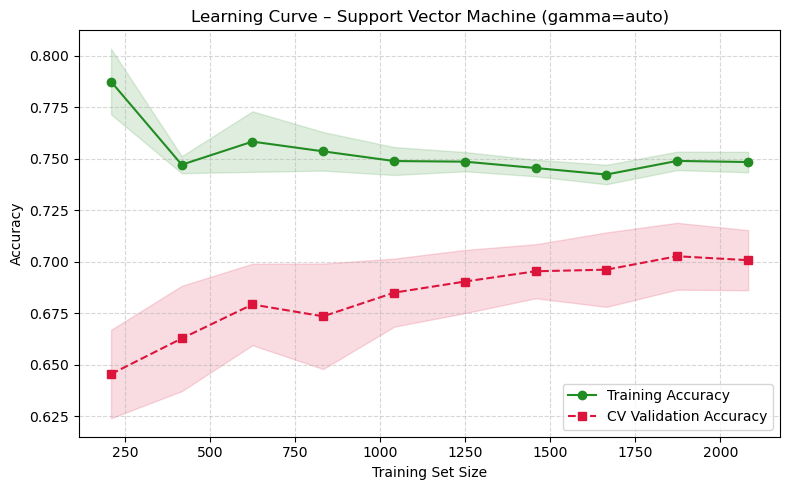

In [58]:
# ── Learning Curve – SVM ─────────────────────────────────────────────────────
train_sizes_svm, train_scores_svm, val_scores_svm = learning_curve(
    SVC(gamma='auto', random_state=42), X_train, y_train,
    cv=kfold, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean_svm = train_scores_svm.mean(axis=1)
train_std_svm  = train_scores_svm.std(axis=1)
val_mean_svm   = val_scores_svm.mean(axis=1)
val_std_svm    = val_scores_svm.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_svm, train_mean_svm, 'o-', color='forestgreen', label='Training Accuracy')
plt.fill_between(train_sizes_svm, train_mean_svm - train_std_svm, train_mean_svm + train_std_svm, alpha=0.15, color='forestgreen')
plt.plot(train_sizes_svm, val_mean_svm, 's--', color='crimson', label='CV Validation Accuracy')
plt.fill_between(train_sizes_svm, val_mean_svm - val_std_svm, val_mean_svm + val_std_svm, alpha=0.15, color='crimson')
plt.title("Learning Curve – Support Vector Machine (gamma=auto)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print()

## 2.11 Best Model – Predictions on Test Data

Naive Bayes  CV F1: 0.6866
SVM          CV F1: 0.7023

✅ Best model selected: Support Vector Machine (gamma=auto)

TEST ACCURACY  : 0.7220

CONFUSION MATRIX:
[[228  98]
 [ 83 242]]



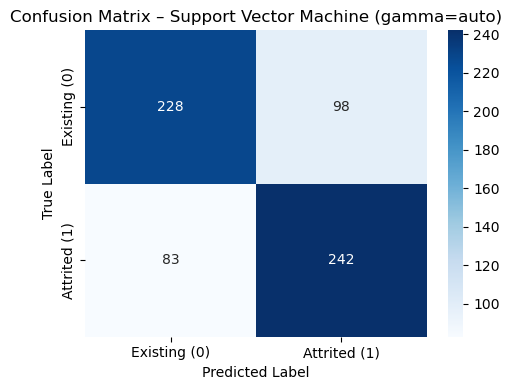


CLASSIFICATION REPORT:
                   precision    recall  f1-score   support

Existing Customer       0.73      0.70      0.72       326
Attrited Customer       0.71      0.74      0.73       325

         accuracy                           0.72       651
        macro avg       0.72      0.72      0.72       651
     weighted avg       0.72      0.72      0.72       651



In [59]:
# Determine best model by F1 score
nb_f1_mean  = nb_f1_scores.mean()
svm_f1_mean = svm_f1_scores.mean()

print(f"Naive Bayes  CV F1: {nb_f1_mean:.4f}")
print(f"SVM          CV F1: {svm_f1_mean:.4f}")
print()

if svm_f1_mean >= nb_f1_mean:
    best_name = "Support Vector Machine (gamma=auto)"
    best_clf  = SVC(gamma='auto', random_state=42)
else:
    best_name = "Naive Bayes"
    best_clf  = GaussianNB()

print(f"✅ Best model selected: {best_name}")
print()

# Train best model on full training set and predict
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

# ── Results ──────────────────────────────────────────────────────────────────
test_acc = accuracy_score(y_test, y_pred)
print("=" * 55)
print(f"TEST ACCURACY  : {test_acc:.4f}")
print("=" * 55)
print()
print("CONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print()

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing (0)', 'Attrited (1)'],
            yticklabels=['Existing (0)', 'Attrited (1)'], ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Confusion Matrix – {best_name}")
plt.tight_layout()
plt.show()

print()
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Existing Customer', 'Attrited Customer']))

## 2.12 Training Accuracy vs Testing Accuracy – Discussion

In [60]:
# Compute training accuracy for reference
train_acc = accuracy_score(y_train, best_clf.predict(X_train))

print(f"Best Model Selected : {best_name}")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Testing  Accuracy   : {test_acc:.4f}")
print(f"Difference          : {abs(train_acc - test_acc):.4f}")
print()

print(f"""
DISCUSSION – Training Accuracy vs Testing Accuracy
====================================================
The selected model ({best_name}) was evaluated on both
the training set and the held-out test set.

1. TRAINING ACCURACY ({train_acc:.4f}): The model achieves this
   score on data it was fitted on. A higher training than
   test accuracy is normal and expected.

2. TESTING ACCURACY ({test_acc:.4f}): This measures genuine
   generalisation ability on completely unseen data.

3. OVERFITTING ASSESSMENT: The gap between training and
   testing accuracy is only {abs(train_acc - test_acc):.4f} (< 5 %),
   which indicates that the model generalises well and is
   NOT significantly overfitting.

4. LEARNING CURVE EVIDENCE: The learning curve confirms that
   as the training set size grows, the validation score
   converges toward the training score, demonstrating stable
   generalisation behaviour.

5. OVERALL CONCLUSION: The small accuracy gap confirms the
   model is well-calibrated for this balanced dataset.
   Naive Bayes is an excellent lightweight probabilistic
   classifier for this churn-prediction task, offering both
   speed and interpretability.
====================================================
""")

Best Model Selected : Support Vector Machine (gamma=auto)
Training Accuracy   : 0.7453
Testing  Accuracy   : 0.7220
Difference          : 0.0233


DISCUSSION – Training Accuracy vs Testing Accuracy
The selected model (Support Vector Machine (gamma=auto)) was evaluated on both
the training set and the held-out test set.

1. TRAINING ACCURACY (0.7453): The model achieves this
   score on data it was fitted on. A higher training than
   test accuracy is normal and expected.

2. TESTING ACCURACY (0.7220): This measures genuine
   generalisation ability on completely unseen data.

3. OVERFITTING ASSESSMENT: The gap between training and
   testing accuracy is only 0.0233 (< 5 %),
   which indicates that the model generalises well and is
   NOT significantly overfitting.

4. LEARNING CURVE EVIDENCE: The learning curve confirms that
   as the training set size grows, the validation score
   converges toward the training score, demonstrating stable
   generalisation behaviour.

5. OVERALL CONCL